CHATBOT WITH TOOLS

In [104]:
print("=== Cell 1: Setup ===")
import os
from dotenv import load_dotenv
load_dotenv()

# Set API keys from env
os.environ["TAVILY_API_KEY"] = "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"
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
print("✓ Cell 1 completed")

=== Cell 1: Setup ===
✓ Cell 1 completed


In [105]:
print("=== Cell 2: Multiply Function ===")
def multiply(a: int, b: int) -> int:
    """
    Multiply two integers together.
    
    Args:
        a (int): The first integer to multiply
        b (int): The second integer to multiply
    
    Returns:
        int: The product of a and b
    """
    return a * b
print("✓ Cell 2 completed")

=== Cell 2: Multiply Function ===
✓ Cell 2 completed


In [106]:
print("=== Cell 3: LLM Init ===")
from langchain.chat_models import init_chat_model

# Initialize LLM using Groq from env
llm = init_chat_model("llama-3.3-70b-versatile", model_provider="groq")
print("✓ Cell 3 completed")

=== Cell 3: LLM Init ===
✓ Cell 3 completed


In [107]:
print("=== Cell 4: Tool Init ===")
from langchain_tavily import TavilySearch

# Initialize Tavily search tool
tool = TavilySearch(max_results=2)
print("✓ Cell 4 completed")

=== Cell 4: Tool Init ===
✓ Cell 4 completed


In [108]:
print("=== Cell 5: Bind Tools ===")
# Bind tools to LLM
tools = [tool, multiply]
llm_with_tools = llm.bind_tools(tools)
print("✓ Cell 5 completed")

=== Cell 5: Bind Tools ===
✓ Cell 5 completed


In [109]:
print("=== Cell 6: State & Chatbot ===")
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}
print("✓ Cell 6 completed")

=== Cell 6: State & Chatbot ===
✓ Cell 6 completed


In [110]:
print("=== Cell 7: Build Graph ===")
# Build the graph
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Compile the graph
graph = graph_builder.compile()
print("✓ Cell 7 completed")

=== Cell 7: Build Graph ===
✓ Cell 7 completed


In [111]:
print("=== Cell 8: Test Graph ===")
# Test the graph
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages": [HumanMessage(content="Multiply 5 by 3")]})
print(response["messages"][-1].content)
print("✓ Cell 8 completed")

=== Cell 8: Test Graph ===

✓ Cell 8 completed


In [112]:
print("=== Cell 8: Test Graph ===")
# Test the graph
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages": [HumanMessage(content="Multiply 5 by 3")]})
print(response["messages"][-1].content)
print("✓ Cell 8 completed")

=== Cell 8: Test Graph ===

✓ Cell 8 completed


In [113]:
def multiply(a: int, b: int) -> int:
    """
    Multiply two integers together.
    
    Args:
        a (int): The first integer to multiply
        b (int): The second integer to multiply
    
    Returns:
        int: The product of a and b
    
    Example:
        >>> multiply(3, 4)
        12
    """
    return a * b

In [114]:
tool=[tool,multiply]

In [115]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x705d74c273e0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x705d74c279b0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine o

=== Cell 9: StateGraph with ToolNode ===


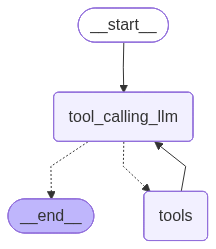

✓ Cell 9 completed


In [116]:
print("=== Cell 9: StateGraph with ToolNode ===")
# StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory_saver = MemorySaver()
# Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Adding the edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is tool call
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

# Compile the graph
graph = builder.compile(checkpointer=memory_saver)

# Visualize
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass
print("✓ Cell 9 completed")

In [117]:
print("=== Cell 11: Test with Multiply (No Internet Required) ===")
# Test with multiply function (doesn't require internet)
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": [HumanMessage(content="Multiply 7 by 6")]}, config=config)
print(response["messages"][-1].content)
print("✓ Cell 11 completed")

=== Cell 11: Test with Multiply (No Internet Required) ===
The result of multiplying 7 by 6 is 42.
✓ Cell 11 completed


In [118]:
print("=== Test with Search Query ===")
# Test the graph with a search query (requires internet)
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": [HumanMessage(content="what is the recent ai news")]}, config=config)
print(response["messages"][-1].content)
print("✓ Test completed")

=== Test with Search Query ===
Based on the search results, the recent AI news includes the launch of OpenAI's new models, Sol, Terra, and Luna, which are part of the GPT-5.6 family. These models are said to be the strongest yet for coding, biology, and cybersecurity. Additionally, there is a trend of AI-generated code changes reaching production without human oversight, with the share of such changes increasing in the past six months. 

It's worth noting that the information provided is based on the search results and may not be exhaustive or up-to-date. For more information, you can visit the provided links or search for more recent news on the topic.
✓ Test completed


In [119]:
response["messages"][-1].content

"Based on the search results, the recent AI news includes the launch of OpenAI's new models, Sol, Terra, and Luna, which are part of the GPT-5.6 family. These models are said to be the strongest yet for coding, biology, and cybersecurity. Additionally, there is a trend of AI-generated code changes reaching production without human oversight, with the share of such changes increasing in the past six months. \n\nIt's worth noting that the information provided is based on the search results and may not be exhaustive or up-to-date. For more information, you can visit the provided links or search for more recent news on the topic."

In [120]:
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": [HumanMessage(content="what is the recent ai news")]}, config=config)

In [121]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 7 by 6
================================== Ai Message ==================================
Tool Calls:
  multiply (cvztg6wtb)
 Call ID: cvztg6wtb
  Args:
    a: 7
    b: 6
================================= Tool Message =================================
Name: multiply

42
================================== Ai Message ==================================

The result of multiplying 7 by 6 is 42.
================================ Human Message =================================

what is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (bqaagrsfp)
 Call ID: bqaagrsfp
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results"

In [122]:
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": [HumanMessage(content="what is 5 multiplied by 3 and then multiply the result by 2")]}, config=config)
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Multiply 7 by 6
================================== Ai Message ==================================
Tool Calls:
  multiply (cvztg6wtb)
 Call ID: cvztg6wtb
  Args:
    a: 7
    b: 6
================================= Tool Message =================================
Name: multiply

42
================================== Ai Message ==================================

The result of multiplying 7 by 6 is 42.
================================ Human Message =================================

what is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (bqaagrsfp)
 Call ID: bqaagrsfp
  Args:
    query: recent AI news
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results"

ReAct Agent Architecture

=== Cell 9: StateGraph with ToolNode ===


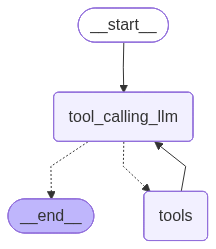

✓ Cell 9 completed


In [123]:
print("=== Cell 9: StateGraph with ToolNode ===")
# StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory_saver = MemorySaver()
# Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Adding the edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is tool call
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

# Compile the graph
graph = builder.compile(checkpointer=memory_saver)

# Visualize
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass
print("✓ Cell 9 completed")

In [124]:
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": [HumanMessage(content="what is the recent ai news and multiply 5 by 3")]}, config=config)
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news and multiply 5 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ttehjyd37)
 Call ID: ttehjyd37
  Args:
    query: recent AI news
    topic: news
  multiply (xvwx1dxyk)
 Call ID: xvwx1dxyk
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/06/24/companies-are-scrambling-to-stop-employees-from-maxing-out-ai-budgets-with-small-tasks/", "title": "Companies are scrambling to stop employees from maxing out AI budgets with small tasks - TechCrunch", "score": 0.8051581, "published_date": "Wed, 24 Jun 2026 20:09:45 GMT", "content": "Founder Summit ticket savings of up to $190 end June 26. After the AI industry enc

Adding Memory In Agentic Graph

In [125]:
config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": [HumanMessage(content="Hello my name is Moeen ")]}, config=config)
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news and multiply 5 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ttehjyd37)
 Call ID: ttehjyd37
  Args:
    query: recent AI news
    topic: news
  multiply (xvwx1dxyk)
 Call ID: xvwx1dxyk
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/06/24/companies-are-scrambling-to-stop-employees-from-maxing-out-ai-budgets-with-small-tasks/", "title": "Companies are scrambling to stop employees from maxing out AI budgets with small tasks - TechCrunch", "score": 0.8051581, "published_date": "Wed, 24 Jun 2026 20:09:45 GMT", "content": "Founder Summit ticket savings of up to $190 end June 26. After the AI industry enc

In [126]:

config = {"configurable": {"thread_id": "1"}}
response = graph.invoke({"messages": [HumanMessage(content="what is my name?")]}, config=config)
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news and multiply 5 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (ttehjyd37)
 Call ID: ttehjyd37
  Args:
    query: recent AI news
    topic: news
  multiply (xvwx1dxyk)
 Call ID: xvwx1dxyk
  Args:
    a: 5
    b: 3
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://techcrunch.com/2026/06/24/companies-are-scrambling-to-stop-employees-from-maxing-out-ai-budgets-with-small-tasks/", "title": "Companies are scrambling to stop employees from maxing out AI budgets with small tasks - TechCrunch", "score": 0.8051581, "published_date": "Wed, 24 Jun 2026 20:09:45 GMT", "content": "Founder Summit ticket savings of up to $190 end June 26. After the AI industry enc

=== Cell 9: StateGraph with ToolNode ===


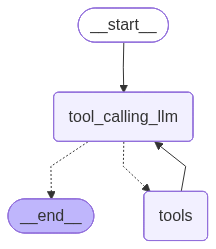

✓ Cell 9 completed


In [127]:
print("=== Cell 9: StateGraph with ToolNode ===")

from langgraph.graph import StateGraph, START
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

# Create Memory
memory_saver = MemorySaver()

# Node definition
def tool_calling_llm(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

# Build Graph
builder = StateGraph(State)

builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")

builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

builder.add_edge("tools", "tool_calling_llm")

# Compile Graph
graph = builder.compile(checkpointer=memory_saver)

# Visualize
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

print("✓ Cell 9 completed")

In [128]:
from langchain_core.messages import HumanMessage

config = {
    "configurable": {
        "thread_id": "1"
    }
}

response = graph.invoke(
    {
        "messages": [
            HumanMessage(content="Hi, my name is Moeen.")
        ]
    },
    config=config
)

print(response["messages"][-1].content)

Hello Moeen, it's nice to meet you. Is there something I can help you with or would you like to chat?


In [129]:
response = graph.invoke(
    {
        "messages": [
            HumanMessage(content="What is my name?")
        ]
    },
    config=config
)

print(response["messages"][-1].content)

Your name is Moeen.


STREAMING


In [130]:
from langgraph.checkpoint.memory import MemorySaver
more_memory_saver = MemorySaver()

In [131]:
def superbot(state: State):
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

In [133]:
graph=StateGraph(State)

#node
graph.add_node("superbot", superbot)

#edges

graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder=graph.compile(checkpointer=more_memory_saver)

#display
from  IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    pass

In [134]:
def superbot(state: State):
    
    return {"messages":[llm.invoke(state["messages"])]}

In [135]:
#Invocation
config = {"configurable": {"thread_id": "1"}}
graph_builder.invoke({"messages": [HumanMessage(content="Hello, my name is Moeen.And I like cricket")]}, config=config)

{'messages': [HumanMessage(content='Hello, my name is Moeen.And I like cricket', additional_kwargs={}, response_metadata={}, id='f542581b-e3a7-4732-b160-fcc9c660ebed'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '94gqrgsmb', 'function': {'arguments': '{"query":"cricket news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1763, 'total_tokens': 1794, 'completion_time': 0.115813904, 'completion_tokens_details': None, 'prompt_time': 0.090546272, 'prompt_tokens_details': None, 'queue_time': 0.015744184, 'total_time': 0.206360176}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0f7a-91c7-7112-ac98-d22f4836dad1-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'cricket news', 'time_range': 'day',

Streaming

Methods.stream() and astream

these methods are sync and async methods for streaming back results

ADDING parameters in streaming modes for graph state
Values=this streams the full state of the graph after each node is call
Updates=this stream s updates to the state of the graph

In [ ]:
config = {"configurable": {"thread_id": "1"}}
for chunk in graph_builder.stream(
    {"messages": [HumanMessage(content="Hello, my name is Moeen.And I like cricket")]},
    config=config,
    stream_mode="updates",
):
    if isinstance(chunk, dict):
        if "messages" in chunk:
            for m in chunk["messages"]:
                if hasattr(m, "pretty_print"):
                    m.pretty_print()
                else:
                    print(m)
        elif "updates" in chunk:
            print(chunk["updates"])
        else:
            print(chunk)
    else:
        print(chunk)

================================ Human Message =================================

Hello, my name is Moeen.And I like cricket
================================== Ai Message ==================================
Tool Calls:
  tavily_search (94gqrgsmb)
 Call ID: 94gqrgsmb
  Args:
    query: cricket news
    time_range: day
    topic: news
================================ Human Message =================================

Hello, my name is Moeen.And I like cricket
================================== Ai Message ==================================
Tool Calls:
  tavily_search (sbf5vdbxh)
 Call ID: sbf5vdbxh
  Args:
    query: latest cricket updates
    time_range: day
    topic: news
================================ Human Message =================================

Hello, my name is Moeen.And I like cricket
================================== Ai Message ==================================
Tool Calls:
  tavily_search (z6tjdxpvv)
 Call ID: z6tjdxpvv
  Args:
    query: Moeen cricket
    time_range: month
 

In [145]:
config = {"configurable": {"thread_id": "1"}}
for chunk in graph_builder.stream(
    {"messages": [HumanMessage(content="Hello, my name is Moeen.And I like cricket")]},
    config=config,
    stream_mode="updates",
):
    if isinstance(chunk, dict):
        if "messages" in chunk:
            for m in chunk["messages"]:
                if hasattr(m, "pretty_print"):
                    m.pretty_print()
                else:
                    print(m)
        elif "updates" in chunk:
            print(chunk["values"])
        else:
            print(chunk)
    else:
        print(chunk)

{'superbot': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ck65fmk9z', 'function': {'arguments': '{"query":"latest cricket news and updates","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 2189, 'total_tokens': 2222, 'completion_time': 0.053245628, 'completion_tokens_details': None, 'prompt_time': 0.163032049, 'prompt_tokens_details': None, 'queue_time': 0.00849486, 'total_time': 0.216277677}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0f90-6061-7722-92d6-643741e88803-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'latest cricket news and updates', 'time_range': 'day', 'topic': 'news'}, 'id': 'ck65fmk9z', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_

Starting fresh the streaming 

In [146]:
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({"messages": [HumanMessage(content="Hello, my name is Moeen.And I like cricket")]}, config=config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '60qavwm5v', 'function': {'arguments': '{"end_date":null,"exclude_domains":null,"include_domains":null,"include_images":false,"query":"cricket news","search_depth":"basic","start_date":null,"time_range":null,"topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 1763, 'total_tokens': 1829, 'completion_time': 0.204986849, 'completion_tokens_details': None, 'prompt_time': 0.221829807, 'prompt_tokens_details': None, 'queue_time': 0.201693853, 'total_time': 0.426816656}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0f97-de58-7de2-88b9-57043603b27a-0', tool_calls=[{'name': 'tavily_search', 'args': {'end_date': None, 'exclude_domains': None, 'include_domains':

In [147]:
for chunk in graph_builder.stream({"messages": [HumanMessage(content="Hello, my name is Moeen.And I like cricket")]}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hello, my name is Moeen.And I like cricket', additional_kwargs={}, response_metadata={}, id='84d05dc2-f98e-4ed8-980d-39af00ca73d1'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '60qavwm5v', 'function': {'arguments': '{"end_date":null,"exclude_domains":null,"include_domains":null,"include_images":false,"query":"cricket news","search_depth":"basic","start_date":null,"time_range":null,"topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 66, 'prompt_tokens': 1763, 'total_tokens': 1829, 'completion_time': 0.204986849, 'completion_tokens_details': None, 'prompt_time': 0.221829807, 'prompt_tokens_details': None, 'queue_time': 0.201693853, 'total_time': 0.426816656}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f0f9